<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fff;">-----------------------------------
    
<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fa9200;">Use Indicators data to build LSTM Equivalent
    
<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fff;">-----------------------------------

In [79]:
#!pip install torch
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117 --upgrade --force-reinstall --user
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 --upgrade --force-reinstall --user

Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download.pytorch.org/whl/cu118/torch-2.4.1%2Bcu118-cp39-cp39-win_amd64.whl (2695.3 MB)
  Using cached https://download.pytorch.org/whl/cu118/torchvision-0.19.1%2Bcu118-cp39-cp39-win_amd64.whl (5.0 MB)
  Using cached https://download.pytorch.org/whl/cu118/torchaudio-2.4.1%2Bcu118-cp39-cp39-win_amd64.whl (4.0 MB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.9.0-py3-none-any.whl (32 kB)
  Using cached https://download.pytorch.org/whl/filelock-3.13.1-py3-none-any.whl (11 kB)
  Using cached https://download.pytorch.org/whl/sympy-1.12-py3-none-any.whl (5.7 MB)
  Using cached https://download.pytorch.org/whl/networkx-3.2.1-py3-none-any.whl (1.6 MB)
  Using cached https://download.pytorch.org/whl/fsspec-2024.2.0-py3-none-any.whl (170 kB)
  Using cached https://download.pytorch.org/whl/Jinja2-3.1.3-py3-none-any.whl (133 kB)
  Using cached https://download.pytorch.org/whl/pillow-10.2.0-cp39-c

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.5.0 requires daal==2021.4.0, which is not installed.
anaconda-project 0.10.2 requires ruamel-yaml, which is not installed.
scipy 1.7.3 requires numpy<1.23.0,>=1.16.5, but you have numpy 1.26.3 which is incompatible.
numba 0.55.1 requires numpy<1.22,>=1.18, but you have numpy 1.26.3 which is incompatible.
jupyter-server 1.13.5 requires pywinpty<2; os_name == "nt", but you have pywinpty 2.0.2 which is incompatible.
appcenter 3.2.1 requires azure-storage-blob<3.0

In [1]:
!nvidia-smi

Fri Sep 20 12:59:26 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 551.61                 Driver Version: 551.61         CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro M1200                 WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A    0C    P8             N/A /  200W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Import Packages

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import Dataset, DataLoader
import itertools
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from datetime import date, datetime, timedelta
import os
import re
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import statsmodels.formula.api as sm
import statsmodels.stats.power as smp
from scipy import stats
import yfinance as yf
import plotly.express as px
import plotly.graph_objects as go
import plotly
from scipy.signal import argrelextrema
from collections import defaultdict
import sqlite3
import warnings
warnings.filterwarnings("ignore")
import Indicators
import Measurement
import Charts
torch.__version__

'2.4.1+cu118'

In [3]:
#torch.cuda.current_device()
if torch.cuda.is_available():
    print("GPU is available!")
else:
    print("GPU is not available.")

GPU is available!


### Add Variables

In [4]:
M = 80
K = 500
window = 7
smoothing = 7
events = {'ihs_event':'bull','hs_event':'bear','fw_event':'bull','rw_event':'bear'}
bound = 0.03
SMAs = [30,60,90]

### Run Functions to Get Data and Indicators

In [5]:
df3, final4 = Measurement.main(events, SMAs, smoothing, window, M, K, bound)

BRK.B: No data found, symbol may be delisted
'DataFrame' object has no attribute 'Datetime'
BF.B: Period '500d' is invalid, must be one of ['1mo', '3mo', '6mo', 'ytd', '1y', '2y', '5y', '10y', 'max']
'DataFrame' object has no attribute 'Datetime'


### Keep only columns Needed

In [6]:
cols = ['ticker','date','open','high','low','close','SMA30','SMA60','SMA90','rw_event','rw_event_none','rw_event_group',
        'rw_event_start_time','rw_event_end_time']
df4 = df3[cols].copy()
df4.head(2)

,ticker,date,open,high,low,close,SMA30,SMA60,SMA90,rw_event,rw_event_none,rw_event_group,rw_event_start_time,rw_event_end_time
0,ZTS,2022-09-26 09:30:00,149.750000,151.259995,149.610001,151.210007,NaN,NaN,NaN,0,1,1,2022-09-26 09:30:00,2024-09-20 12:30:00
1,ZTS,2022-09-26 10:30:00,151.270004,151.389999,149.509995,149.509995,NaN,NaN,NaN,0,1,1,2022-09-26 09:30:00,2024-09-20 12:30:00


### Test Results for One Inidicator

In [7]:
event = 'rw_event'
final4.head(2)

,index,ticker,event,event_observations,event_start_time,event_end_time,after_event_observations,after_event_mean,after_event_start_time,after_event_end_time,count,mean,min,median,max,Indicator,event_count,event_success,stock_success
0,0,A,rw_event,36.0,2023-10-31 14:30:00,2023-11-07 14:30:00,1.0,-0.049453,2023-11-07 14:30:00,2023-11-24 09:30:00,2749.0,-0.044361,-0.223545,-0.034741,0.056347,1,1.0,0.793233,1.0
1,1,A,rw_event,51.0,2023-12-11 10:30:00,2023-12-20 11:30:00,1.0,-0.088146,2023-12-20 11:30:00,2024-01-08 13:30:00,2749.0,-0.044361,-0.223545,-0.034741,0.056347,1,1.0,0.793233,1.0


### Join with Final to identify Successful Indicator Results

In [8]:
rw_final4 = final4[(final4.event == event)&(final4.Indicator==1)].copy()
test = pd.merge(df4, rw_final4[['event_start_time','ticker','Indicator','median']], left_on = [event + '_start_time','ticker'], right_on = ['event_start_time','ticker'], 
    how='left').rename(columns={'Indicator': event + '_indicator'}).drop(['event_start_time'], axis=1)
test[event+'_indicator'] = test[event + '_indicator'].fillna(0)
test['median'] = test['median'].fillna(0)
test[event+'_indicator2'] = np.where((test[event + '_indicator'] == 1) & (test[event + '_indicator'].shift(-1) == 0), 1, 0)
test.head(2)

,ticker,date,open,high,low,close,SMA30,SMA60,SMA90,rw_event,rw_event_none,rw_event_group,rw_event_start_time,rw_event_end_time,rw_event_indicator,median,rw_event_indicator2
0,ZTS,2022-09-26 09:30:00,149.750000,151.259995,149.610001,151.210007,NaN,NaN,NaN,0,1,1,2022-09-26 09:30:00,2024-09-20 12:30:00,0.0,0.0,0
1,ZTS,2022-09-26 10:30:00,151.270004,151.389999,149.509995,149.509995,NaN,NaN,NaN,0,1,1,2022-09-26 09:30:00,2024-09-20 12:30:00,0.0,0.0,0


### Validate the Join

In [9]:
event2 = event + '_indicator'
test.groupby([event])[event2].describe()

,count,mean,std,min,25%,50%,75%,max
rw_event,,,,,,,,
0,1683396.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,42995.0,0.382021,0.485887,0.0,0.0,0.0,1.0,1.0


### <ins>Note:</ins> Adding in Change from SMA

In [10]:
smaList = [x for x in df4.columns if 'SMA' in x]
for s in smaList:
    test[s + '_chng'] = (test['close'] - test[s])/test['close']
test.head(2)

,ticker,date,open,high,low,close,SMA30,SMA60,SMA90,rw_event,rw_event_none,rw_event_group,rw_event_start_time,rw_event_end_time,rw_event_indicator,median,rw_event_indicator2,SMA30_chng,SMA60_chng,SMA90_chng
0,ZTS,2022-09-26 09:30:00,149.750000,151.259995,149.610001,151.210007,NaN,NaN,NaN,0,1,1,2022-09-26 09:30:00,2024-09-20 12:30:00,0.0,0.0,0,NaN,NaN,NaN
1,ZTS,2022-09-26 10:30:00,151.270004,151.389999,149.509995,149.509995,NaN,NaN,NaN,0,1,1,2022-09-26 09:30:00,2024-09-20 12:30:00,0.0,0.0,0,NaN,NaN,NaN


In [11]:
pDict = {'open':4,'high':2,'low':3,'close':1}
for x in pDict.keys():
    for y in pDict.keys():
        if pDict[x] < pDict[y]:
            test[x + '_' + y + '_chng'] = (test[x] - test[y])/test[x]
        else:
            continue

test.head(2)

,ticker,date,open,high,low,close,SMA30,SMA60,SMA90,rw_event,...,rw_event_indicator2,SMA30_chng,SMA60_chng,SMA90_chng,high_open_chng,high_low_chng,low_open_chng,close_open_chng,close_high_chng,close_low_chng
0,ZTS,2022-09-26 09:30:00,149.750000,151.259995,149.610001,151.210007,NaN,NaN,NaN,0,...,0,NaN,NaN,NaN,0.009983,0.010908,-0.000936,0.009655,-0.000331,0.010581
1,ZTS,2022-09-26 10:30:00,151.270004,151.389999,149.509995,149.509995,NaN,NaN,NaN,0,...,0,NaN,NaN,NaN,0.000793,0.012418,-0.011772,-0.011772,-0.012574,0.000000


### Run PCA on specified event

In [12]:
test.dropna(inplace=True)
chngList = [x for x in test.columns if 'chng' in x]
X = test[chngList].values
X = StandardScaler().fit_transform(X)
pca_fit = PCA(n_components=2)
pcomp = pca_fit.fit_transform(X)
pcomp

array([[ 0.4822634 , -0.88880115],
       [ 1.39859484, -0.90195503],
       [-0.0393565 ,  2.70185766],
       ...,
       [-1.71336572,  1.12641737],
       [-1.19066987, -0.29722557],
       [-0.64473371, -1.47327638]])

### ADD PCA to DF

In [13]:
test['pca1'] = pcomp[:,0]
test['pca2'] = pcomp[:,0]
test.head(2)

,ticker,date,open,high,low,close,SMA30,SMA60,SMA90,rw_event,...,SMA60_chng,SMA90_chng,high_open_chng,high_low_chng,low_open_chng,close_open_chng,close_high_chng,close_low_chng,pca1,pca2
89,ZTS,2022-10-12 14:30:00,146.475006,146.794006,146.119995,146.490005,147.574646,150.135857,150.252059,0,...,-0.024888,-0.025681,0.002173,0.004592,-0.002430,0.000102,-0.002075,0.002526,0.482263,0.482263
90,ZTS,2022-10-12 15:30:00,146.460007,146.729996,145.820007,145.940002,147.333646,150.068690,150.193503,0,...,-0.028290,-0.029146,0.001840,0.006202,-0.004389,-0.003563,-0.005413,0.000822,1.398595,1.398595


### ScatterPlot PCA Results

In [14]:
#test2 = test.sample(frac=.1).copy()
test2 = test[test[event]==1].copy()
fig = go.Figure()
fig.add_trace(go.Scatter(x=test2[test2[event2]==0].pca1, 
                    y=test2[test2[event2]==0].pca2,
                    mode='markers',
                    name = event + '_fail'
                    ))
fig.add_trace(go.Scatter(x=test2[test2[event2]==1].pca1, 
                    y=test2[test2[event2]==1].pca2,
                    mode='markers',
                    name= event + '_pass',
                    ))
plotly.offline.plot(fig, filename='C:/Users/rschaub/Downloads/test.html')

'C:/Users/rschaub/Downloads/test.html'

### Histogram of PCA Results

In [15]:
fig = px.histogram(test2, x="pca1", color=event2, nbins=200)
plotly.offline.plot(fig, filename='C:/Users/rschaub/Downloads/test.html')

'C:/Users/rschaub/Downloads/test.html'

### Note: The Scatter plot appeared to show that the successful indicators have a tighter distribution, but upon further investigation the historgram appears to show that the distributions are in fact similar but there are less outliers in the successful data set, perhaps due to the smaller number of observations. We can confirm this by picking a significant sample size and using A/B testing

### Create Function for Cohen's d

In [16]:
def cohens_d(group1, group2):
    # Calculating means of the two groups
    mean1, mean2 = np.mean(group1), np.mean(group2)
     
    # Calculating pooled standard deviation
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1 - 1) * std1 ** 2 + (n2 - 1) * std2 ** 2) / (n1 + n2 - 2))
     
    # Calculating Cohen's d
    d = (mean1 - mean2) / pooled_std
     
    return d

### Determine Sample Size

In [17]:
effect_size = 0.01  # The desired effect size (e.g., Cohen's d)
alpha = 0.05  # The significance level (e.g., 0.05)
power = 0.95  # The desired statistical power (e.g., 0.8)

test_a = test2[test2[event2]==0].copy()
test_b = test2[test2[event2]==1].copy()
print(len(test_a),len(test_b))
effect_size = cohens_d(test_a.pca1, test_b.pca1)
print("Cohen's d:", effect_size)

# For a paired t-test
power_analysis = smp.TTestPower()
sample_size = power_analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power)

# Round up to the nearest integer
sample_size = round(sample_size)

print("Required Sample Size:", sample_size)

26526 16272
Cohen's d: -0.026907388785982315
Required Sample Size: 17950


### Run A/B Test

In [18]:
mu_a = test_a.pca1.mean()
mu_b = test_b.pca1.mean()
#t_stat, p_value = stats.ttest_1samp(test_b.pca1, mu_a)
t_stat, p_value = stats.ttest_ind(test_a.pca1, test_b.pca1)
print("T statistic:", t_stat)
print("P-value:", p_value)

T statistic: -2.7021917713879064
P-value: 0.006891117311674055


### Create BoxPlot of DataSets

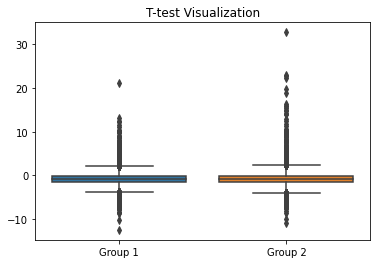

In [21]:
sns.boxplot(data=[test_a.pca1, test_b.pca1])
plt.xticks([0, 1], ['Group 1', 'Group 2'])
plt.title('T-test Visualization')
plt.show()

### Run DBScan

In [22]:
dbscan = DBSCAN(eps=0.1, min_samples=5)
# Fit the model
dbscan.fit(test_b[['pca1','pca2']])
# Get the cluster labels
labels = dbscan.labels_

In [23]:
test_b['db_scan'] = labels
test_b.groupby(['db_scan']).pca1.mean()

db_scan
-1    5.154368
 0   -0.769991
 1    4.485072
 2   -5.385002
 3   -5.117596
 4   -6.372693
 5    6.258144
 6    5.686184
 7    5.394440
Name: pca1, dtype: float64

In [24]:
#test2 = test.sample(frac=.1).copy()
dbList = list(test_b.db_scan.unique())
fig = go.Figure()
for d in dbList:
    fig.add_trace(go.Scatter(x=test_b[test_b['db_scan']==d].pca1, 
                    y=test2[test2[event2]==0].pca2,
                    mode='markers',
                    name = event + '_' + str(d)
                    ))
plotly.offline.plot(fig, filename='C:/Users/rschaub/Downloads/test.html')

'C:/Users/rschaub/Downloads/test.html'

In [25]:
test_b.groupby(['db_scan'])['median'].describe()

,count,mean,std,min,25%,50%,75%,max
db_scan,,,,,,,,
-1,93.0,-0.037150,0.012570,-0.079989,-0.040681,-0.034439,-0.029541,-0.023646
0,16089.0,-0.034241,0.010624,-0.079989,-0.040041,-0.032214,-0.026743,-0.015744
1,39.0,-0.037661,0.011736,-0.068238,-0.040980,-0.038047,-0.028366,-0.021681
2,13.0,-0.039981,0.013546,-0.069343,-0.038047,-0.038047,-0.031670,-0.029232
3,9.0,-0.042094,0.012117,-0.069343,-0.041301,-0.040681,-0.038153,-0.027026
4,11.0,-0.043872,0.014306,-0.069343,-0.048745,-0.036127,-0.034484,-0.031670
5,8.0,-0.039425,0.014333,-0.068238,-0.042746,-0.036466,-0.029541,-0.023853
6,5.0,-0.039493,0.016483,-0.067389,-0.041179,-0.032332,-0.029541,-0.027026
7,5.0,-0.039967,0.012195,-0.053590,-0.051449,-0.038153,-0.029541,-0.027102


### Move on to LSTM

In [46]:
sample = .05
split = .7
lookback = 50
stocks = list(test.ticker.unique())
stocks2 = random.sample(stocks,int(round(sample*len(stocks),0)))
train_stocks = random.sample(stocks2,int(round(split*len(stocks2),0)))
test_stocks = [x for x in stocks2 if x not in train_stocks]
lstm_train1 = test[test.ticker.isin(train_stocks)]['close'].values.astype('float32')
lstm_train2 = test[test.ticker.isin(train_stocks)][event2].values.astype('float32')
lstm_test1 = test[test.ticker.isin(test_stocks)]['close'].values.astype('float32')
lstm_test2 = test[test.ticker.isin(test_stocks)][event2].values.astype('float32')
lstm_train1

array([146.49 , 145.94 , 143.76 , ...,  40.45 ,  40.36 ,  40.415],
      dtype=float32)

In [47]:
len(lstm_train2)

59885

In [28]:
def create_dataset(dataset1, dataset2, lookback):

    X, y = [], []
    for i in range(lookback,len(dataset1)):
        feature = dataset1[i-lookback:i]
        target = dataset2[i]
        X.append(feature)
        y.append(target)
    return torch.tensor(X), torch.tensor(y)

In [48]:
K = 500000
X_train, y_train = create_dataset(lstm_train1[0:K], lstm_train2[0:K], lookback=lookback)
X_test, y_test = create_dataset(lstm_test1[0:K], lstm_test2[0:K], lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([59835, 50]) torch.Size([59835])
torch.Size([23740, 50]) torch.Size([23740])


In [135]:
#dataset = TimeSeriesDataset(lstm_train1[0:K], lookback)
#dataset = X_train
#dataloader = DataLoader(dataset, batch_size=32)

In [37]:
class AirModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=50, hidden_size=50, num_layers=1, batch_first=True)
        self.linear = nn.Linear(50, 1)
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.linear(x)
        return x

In [49]:
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AirModel()
optimizer = optim.Adam(model.parameters())
model.to(device)
loss_fn = nn.MSELoss()
X_train = X_train.cuda()
y_train = y_train.cuda()
X_test = X_test.cuda()
y_test = y_test.cuda()
loader = data.DataLoader(data.TensorDataset(X_train, y_train), shuffle=True, batch_size=10)
 
n_epochs = 50
for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in loader:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # Validation
    #if epoch % 100 != 0:
    #    continue
    model.eval()
    with torch.no_grad():
        y_pred = model(X_train)
        train_rmse = np.sqrt(loss_fn(y_pred.cpu(), y_train.cpu()))
        y_pred = model(X_test)
        test_rmse = np.sqrt(loss_fn(y_pred.cpu(), y_test.cpu()))
    print("Epoch %d: train RMSE %.4f, test RMSE %.4f" % (epoch, train_rmse, test_rmse))

Epoch 0: train RMSE 0.0970, test RMSE 0.1329
Epoch 1: train RMSE 0.0962, test RMSE 0.1308
Epoch 2: train RMSE 0.0961, test RMSE 0.1318
Epoch 3: train RMSE 0.0961, test RMSE 0.1307
Epoch 4: train RMSE 0.0958, test RMSE 0.1314
Epoch 5: train RMSE 0.0979, test RMSE 0.1339
Epoch 6: train RMSE 0.0974, test RMSE 0.1334
Epoch 7: train RMSE 0.0964, test RMSE 0.1308
Epoch 8: train RMSE 0.0971, test RMSE 0.1331
Epoch 9: train RMSE 0.0960, test RMSE 0.1317
Epoch 10: train RMSE 0.0966, test RMSE 0.1325
Epoch 11: train RMSE 0.0965, test RMSE 0.1308
Epoch 12: train RMSE 0.0997, test RMSE 0.1356
Epoch 13: train RMSE 0.0979, test RMSE 0.1314
Epoch 14: train RMSE 0.0958, test RMSE 0.1313
Epoch 15: train RMSE 0.0958, test RMSE 0.1308
Epoch 16: train RMSE 0.0960, test RMSE 0.1317
Epoch 17: train RMSE 0.0957, test RMSE 0.1309
Epoch 18: train RMSE 0.0962, test RMSE 0.1320
Epoch 19: train RMSE 0.0963, test RMSE 0.1308


In [50]:
pd.DataFrame(list(lstm_test2[0:K])).describe()

,0
count,23790.000000
mean,0.017360
std,0.130624
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [51]:
pd.DataFrame(y_pred.cpu()).describe()

,0
count,23740.000000
mean,0.019904
std,0.000008
min,0.018899
25%,0.019908
50%,0.019908
75%,0.019908
max,0.019908


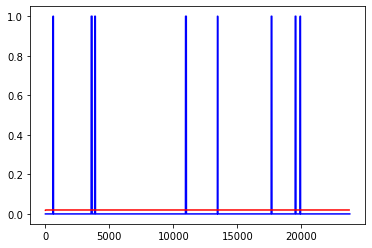

In [52]:
"""
with torch.no_grad():
    # shift train predictions for plotting
    train_plot = np.ones_like(test[event2[0:K].values.astype('float32')) * np.nan
    y_pred = model(X_train)
    #y_pred = y_pred.cpu()
    #train_plot[lookback:K] = model(X_train).cpu()[ -1, :]
    # shift test predictions for plotting
    test_plot = np.ones_like(timeseries) * np.nan
    test_plot[train_size+lookback:len(timeseries)] = model(X_test)[ -1, :]
# plot
"""
plt.plot(list(lstm_test2[0:K]), c='b')
plt.plot(y_pred.cpu(), c='r')
#plt.plot(test_plot, c='g')
plt.show()

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # Get the last hidden state
        return out

In [113]:
if __name__ == "__main__":
    input_size = 50
    hidden_size = 64
    num_layers = 2
    output_size = 1
    batch_size = 32
    sequence_length = 50

    model = LSTMModel(input_size, hidden_size, num_layers, output_size).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters())

    # Generate some dummy data
    #input_data = torch.randn(batch_size, sequence_length, input_size).to(device)
    #target_data = torch.randn(batch_size, output_size).to(device)
    input_data = X_train.to(device)
    target_data = y_train.to(device)
    input_data = input_data.reshape(1,input_data.shape[0],input_data.shape[1])
    target_data = target_data.reshape(1,target_data.shape[0],target_data.shape[1])

    # Training loop
    for epoch in range(10):
        optimizer.zero_grad()
        outputs = model(input_data)
        loss = criterion(outputs, target_data)
        loss.backward()
        optimizer.step()

        print(f"Epoch: {epoch+1}, Loss: {loss.item()}")

Epoch: 1, Loss: 0.01112845167517662
Epoch: 2, Loss: 1.9276785678812303e-05
Epoch: 3, Loss: 0.002304224530234933
Epoch: 4, Loss: 0.0017768401885405183
Epoch: 5, Loss: 0.0008625077898614109
Epoch: 6, Loss: 0.00015286073903553188
Epoch: 7, Loss: 2.7067291739513166e-05
Epoch: 8, Loss: 0.0003094376006629318
Epoch: 9, Loss: 0.00041729697841219604
Epoch: 10, Loss: 0.00028749657212756574


In [80]:
input_data.reshape(1,input_data.shape[0],input_data.shape[1]).shape

torch.Size([1, 118999, 50])

In [132]:
class MyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Assuming df is your pandas DataFrame
#X = df[['feature1', 'feature2']]
#y = df['target']
X = test[test.ticker.isin(train_stocks)]['close'][0:1000]
y = test[test.ticker.isin(train_stocks)][event2][0:1000]

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

train_dataset = MyDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32)

test_dataset = MyDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32)

TypeError: must be real number, not builtin_function_or_method

In [126]:
class MyModel(nn.Module):
    def __init__(self, input_size, output_size):
        super(MyModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

input_size = X_train.shape[0]
output_size = 1  # Adjust if your target is multi-class

model = MyModel(input_size, output_size)

In [127]:
criterion = nn.MSELoss()  # Choose appropriate loss function
optimizer = optim.Adam(model.parameters())

epochs = 100
for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x32 and 800x64)

In [137]:
class TimeSeriesDataset(Dataset):
    def __init__(self, df, sequence_length):
        self.data = df.values
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.data) - self.sequence_length

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx:idx + self.sequence_length, :-1], dtype=torch.float)
        y = torch.tensor(self.data[idx + self.sequence_length, -1], dtype=torch.float)
        return x, y

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        c0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [139]:
df = test.iloc[0:1000][['close','open',event2]]
sequence_length = 10
dataset = TimeSeriesDataset(df, sequence_length)
dataloader = DataLoader(dataset, batch_size=32)

# Model definition
input_size = df.shape[1] - 1  # Number of features
hidden_size = 64
num_layers = 2
output_size = 1  # Number of target values
model = LSTMModel(input_size, hidden_size, num_layers, output_size)

# Training
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
for epoch in range(10):
    for x, y in dataloader:
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

# Prediction
with torch.no_grad():
    predictions = model(dataset.data[:, :-1].unsqueeze(0).float())

print(predictions)

AttributeError: 'numpy.ndarray' object has no attribute 'unsqueeze'